In [321]:
!pip install -qr requirements.txt

In [322]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [323]:
from scipy.io import mmread
import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

# deep stuff
import torch
from torch_geometric.utils import from_networkx

In [324]:
from src.community_results import community_metrics, plot_communities, community_size_hist
from src.clustering import label_propagation, louvain, leiden, kmeans, optics
from src.DGIModel import DGIModel
from src.GAT import  GAT, contrastive_loss
from src.tune import tune, tune_variance_contrastive

In [325]:
data_path = './data'

enron_path = f'{data_path}/email_enron_only.mtx'
univ_path = f'{data_path}/email_univ.edges'

In [326]:
# assume undirected graph
def read_adj_file(file, skip_rows: int = 0):
    lines = []
    with open(file, 'r') as f:
        lines = f.readlines()

    E = np.asarray([l.split() for l in lines[skip_rows:]]).astype(int)
    # index from 0
    E = E - E.min()

    adj = np.zeros((E.max() + 1, E.max() + 1))

    for (u, v) in E:
        adj[u, v] = 1
        adj[v, u] = 1

    return adj

# Load datasets

In [327]:
graphs = dict()

In [328]:
# not in standard mtx format
graphs['univ'] = nx.Graph(read_adj_file(univ_path))
graphs['univ'].number_of_nodes(), graphs['univ'].number_of_edges(), graphs['univ'].is_directed()

(1133, 5451, False)

In [329]:
graphs['enron'] = nx.Graph(mmread(enron_path).toarray())
graphs['enron'].number_of_nodes(), graphs['enron'].number_of_edges(), graphs['enron'].is_directed()

(143, 623, False)

In [330]:
graphs['karate'] = nx.karate_club_graph()
graphs['karate'].number_of_nodes(), graphs['karate'] .number_of_edges(), graphs['karate'].is_directed()

(34, 78, False)

# Select Dataset

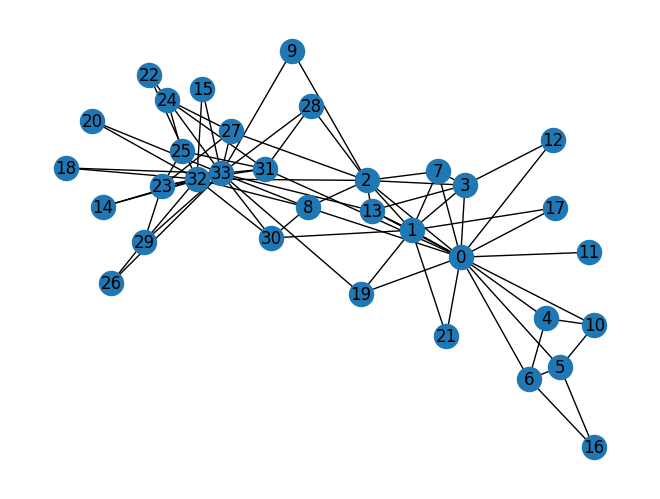

In [331]:
sel_graph = 'karate'
g = graphs[sel_graph]
nx.draw(g, with_labels=True)

### Metrics Dataframe

In [332]:
columns = ['Algorithm',
           'Number of Communities',
           'Average Community Size',
           'Modularity',
           'Average Cluster Coefficients',
           'Number of connected components',
           'Coverage',
           'Performance',
           'Iterations',
           'Resolution']

metrics = pd.DataFrame(columns=columns)

# Apply graph based clustering

## Label Propagation

### Hyperparameter selection

2 approaches will be considered for label propagation:
1. Single run label propagation.
2. Label propagation with aggregation on multiple runs.

In [333]:
lp_trials = []

Single run experiment:

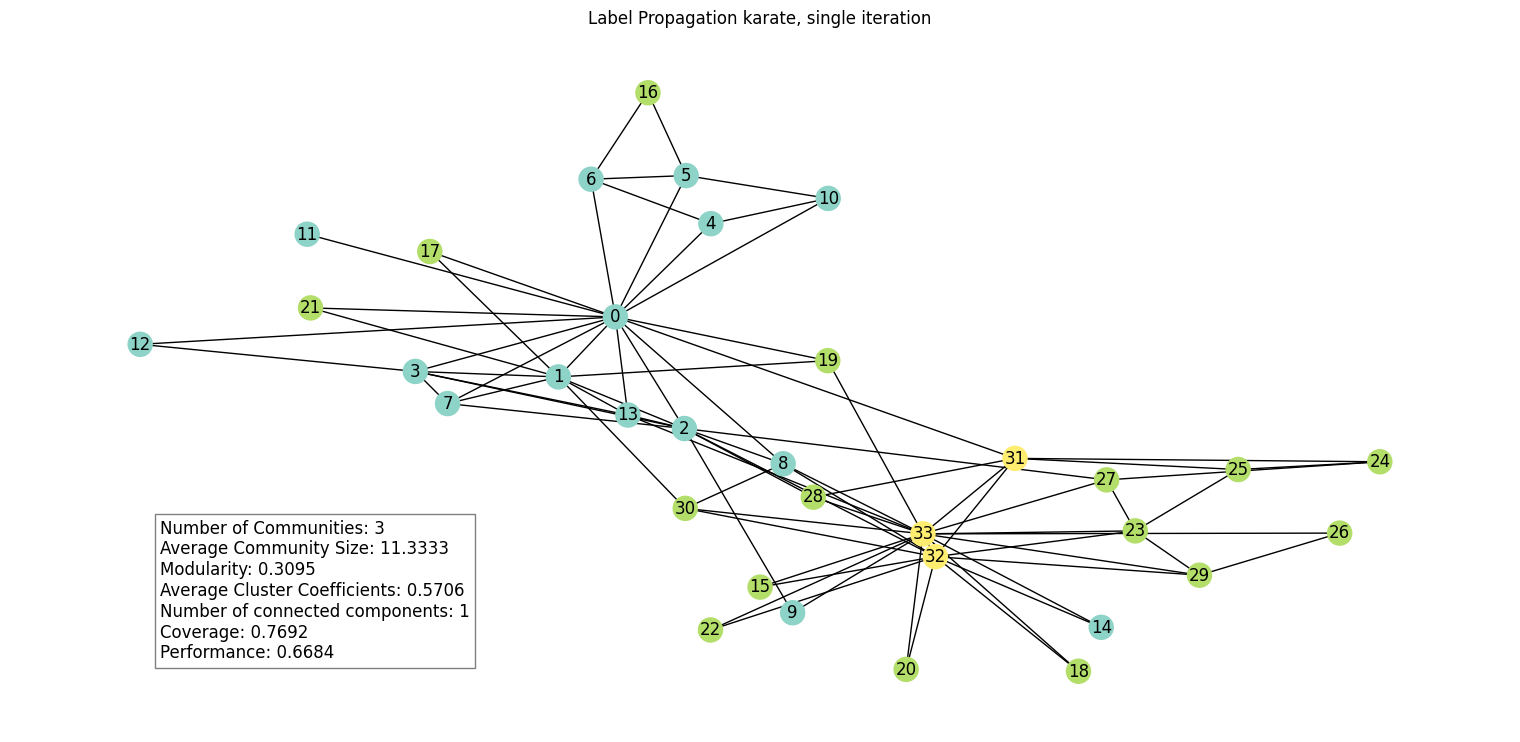

In [334]:
# single run
lp_labels = label_propagation(g)

# Calculate metrics for LP
lp_metrics = community_metrics(g, lp_labels)
lp_trials.append({**lp_metrics, 'Iterations': 1})
plot_communities(g, lp_labels, title=f"Label Propagation {sel_graph}, single iteration", metrics=lp_metrics)

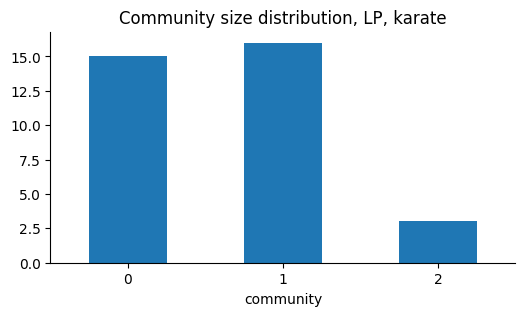

In [335]:
community_size_hist(lp_labels, title=f"Community size distribution, LP, {sel_graph}")

Experiments with 1, 5 and 15 iterations:

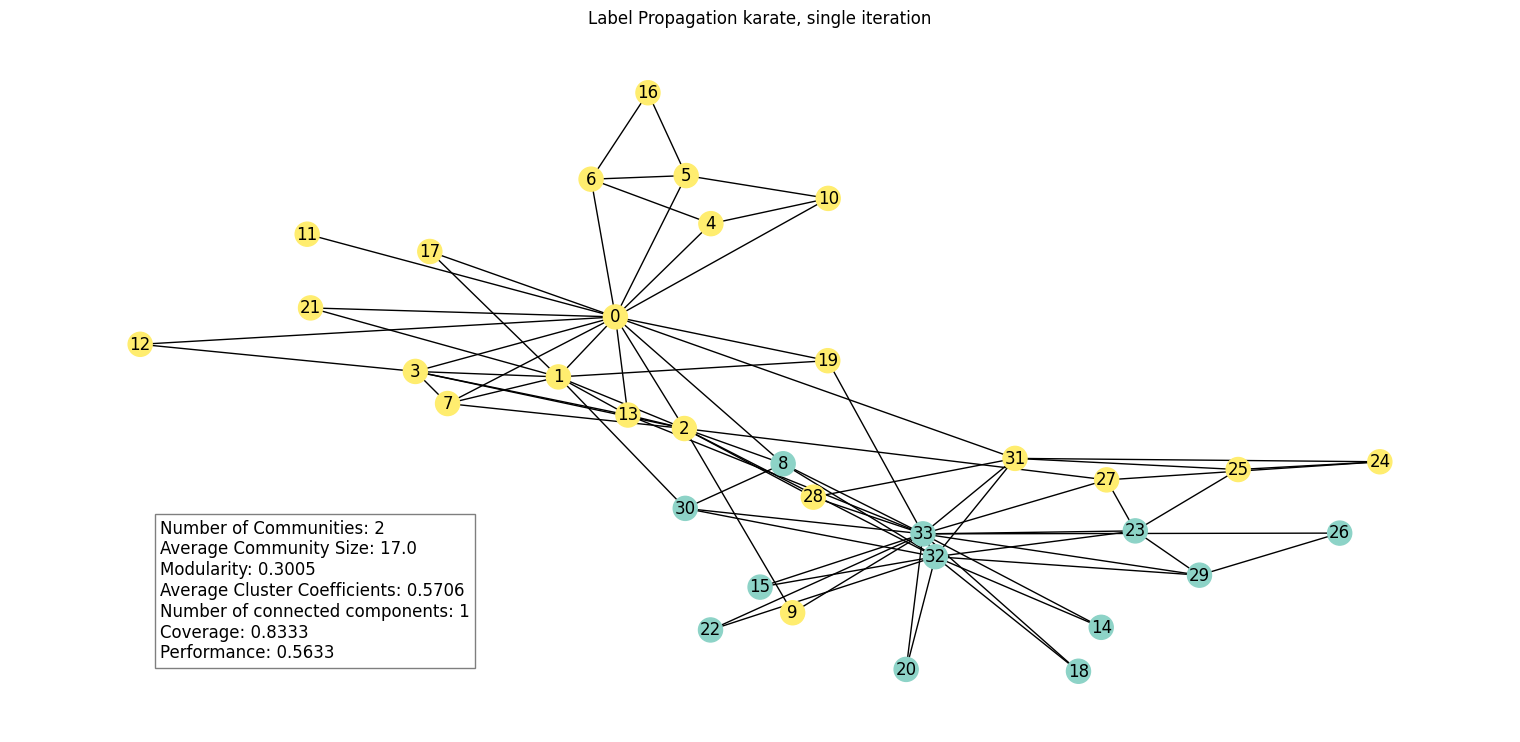

In [336]:
# single run
lp_labels = label_propagation(g, aggr_runs=5)

# Calculate metrics for LP
lp_metrics = community_metrics(g, lp_labels)
lp_trials.append({**lp_metrics, 'Iterations': 5})
plot_communities(g, lp_labels, title=f"Label Propagation {sel_graph}, single iteration", metrics=lp_metrics)

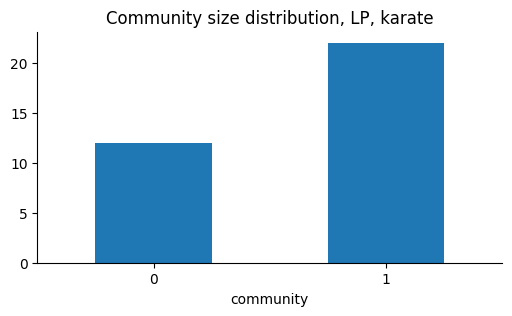

In [337]:
community_size_hist(lp_labels, title=f"Community size distribution, LP, {sel_graph}")

Experiments with 1, 5 and 15 iterations:

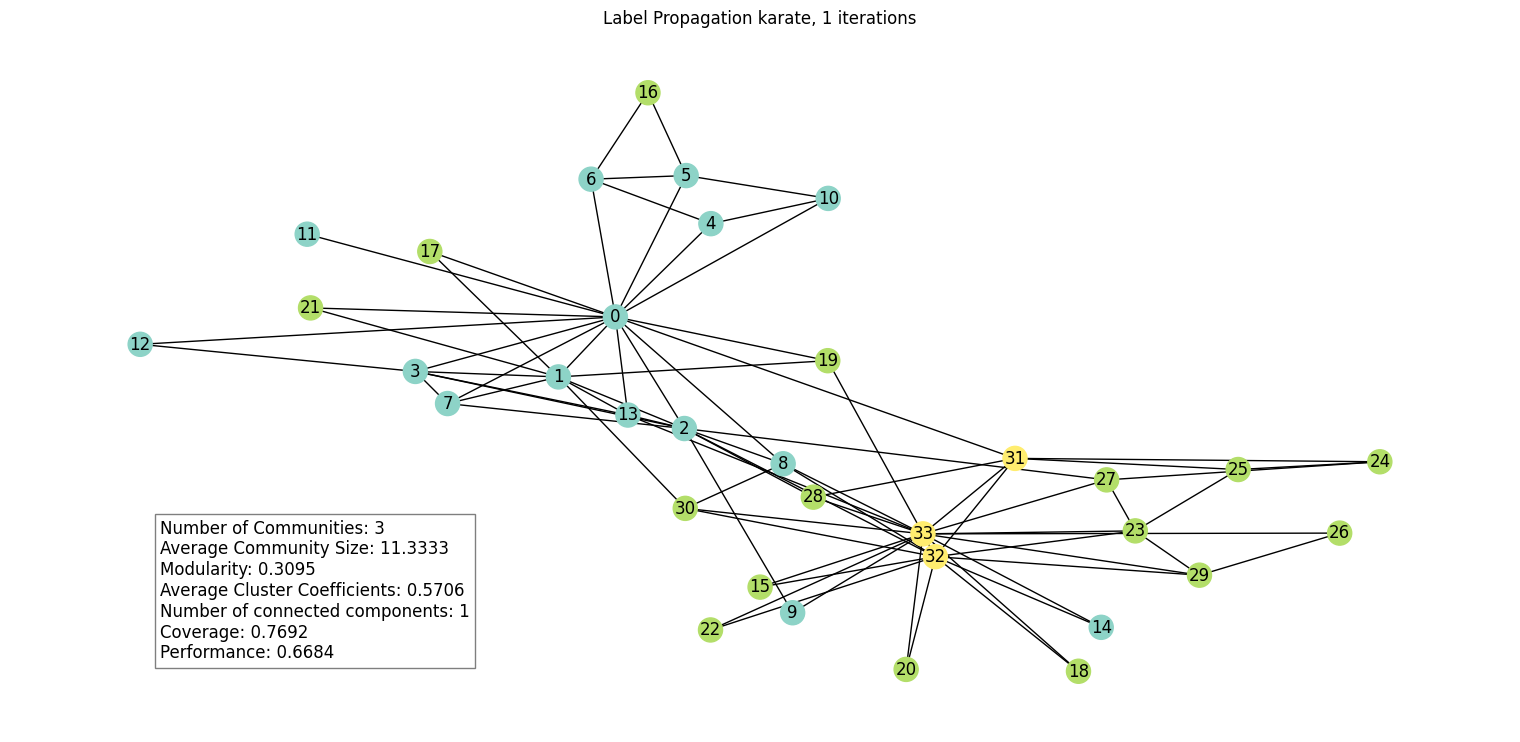

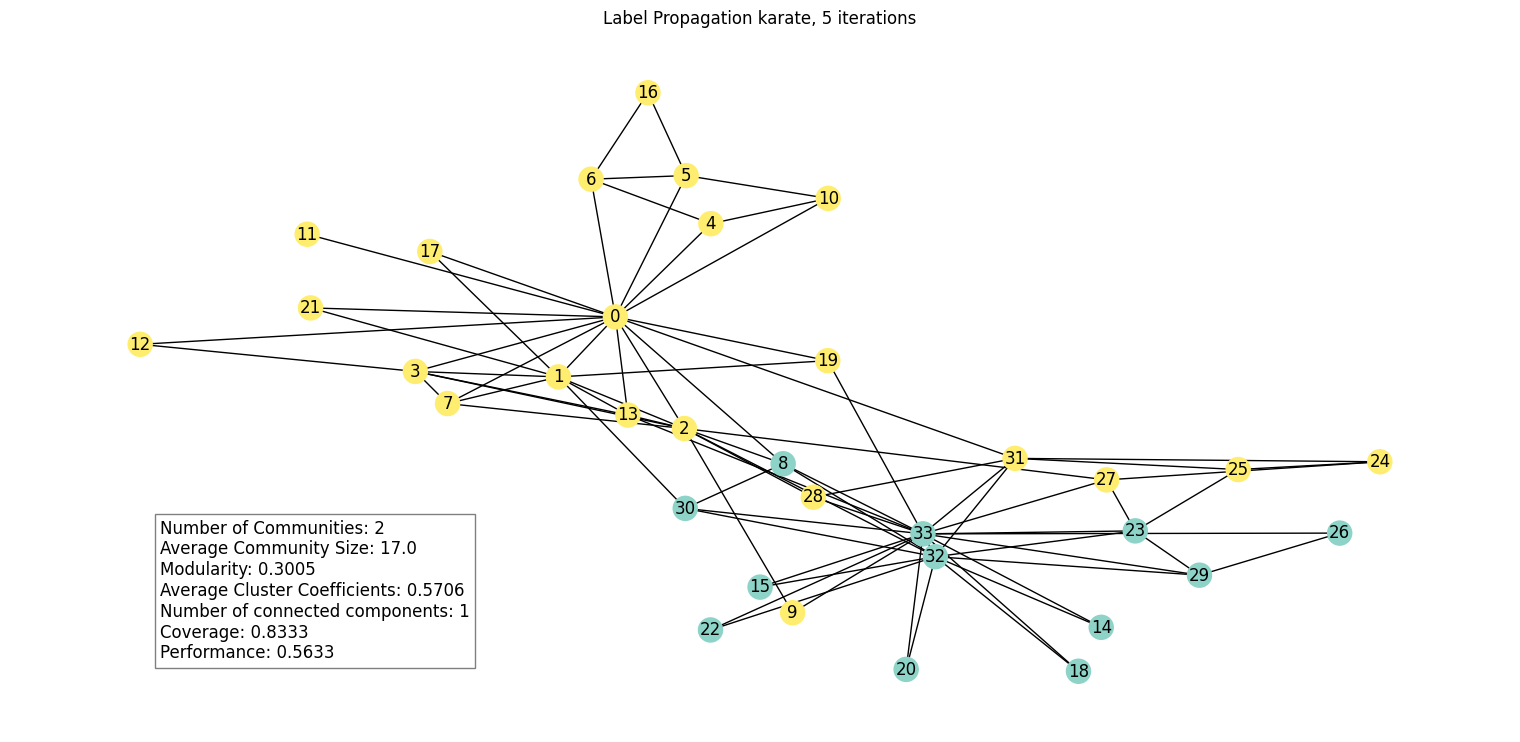

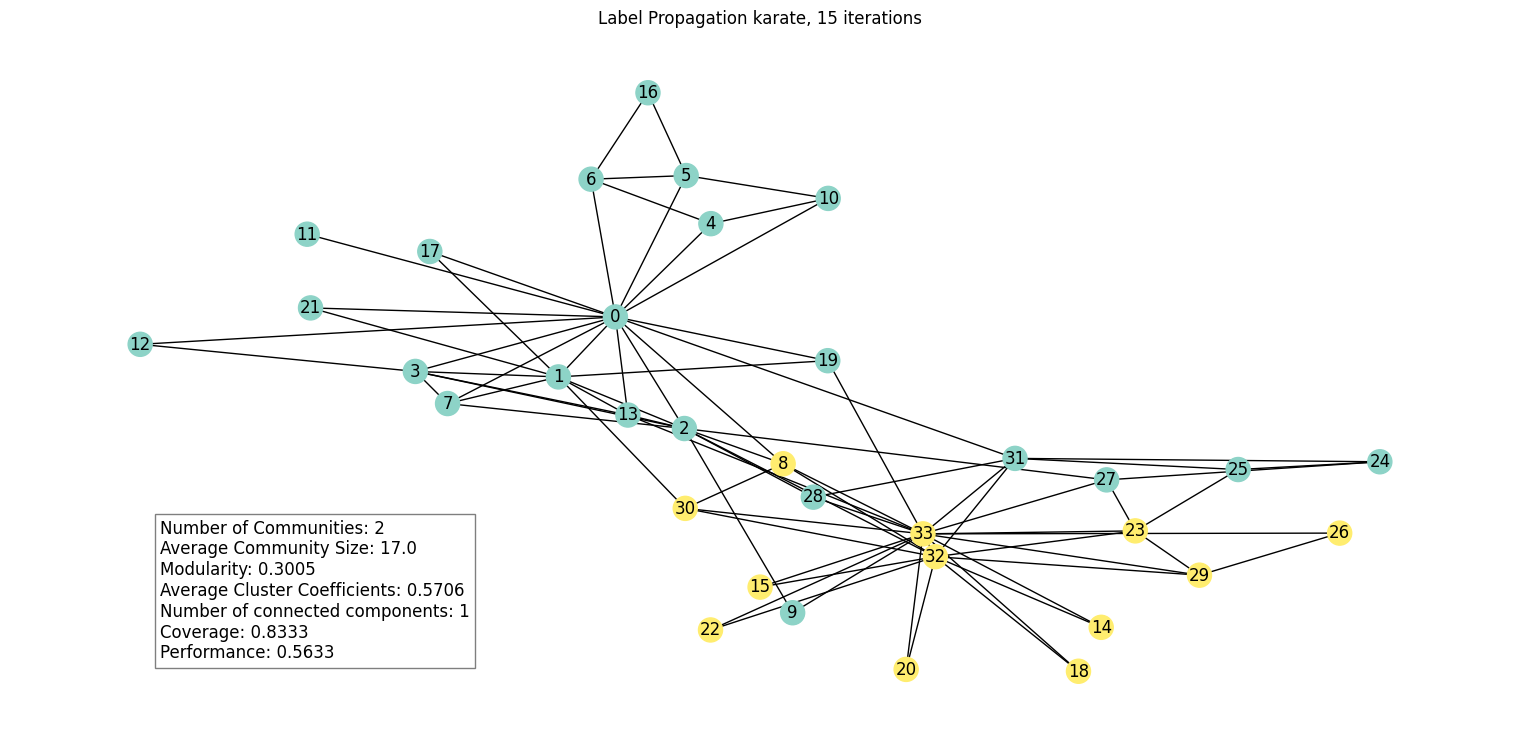

In [338]:
# based on results in paper, experiments with higher value 
# confirm authors' statement that modularity doesn't change much
for i in (1, 5, 15):
    lp_labels = label_propagation(g, aggr_runs=i)

    # Calculate metrics for LP
    lp_metrics = community_metrics(g, lp_labels)
    lp_trials.append({**lp_metrics, 'Iterations': i})
    plot_communities(g, lp_labels, title=f"Label Propagation {sel_graph}, {i} iterations", metrics=lp_metrics)

### Model evaluation

In [339]:
lp_df = pd.DataFrame(lp_trials)

# calculate execution time and metrics for best model
start_time = time.time()
lp_labels = label_propagation(g, aggr_runs=int(lp_df.loc[lp_df['Modularity'].idxmax(), 'Iterations']))
end_time = time.time()
lp_time = end_time - start_time
lp_metrics = community_metrics(g, lp_labels)

## Louvain

### Hyperparameter selection

For Louvain algorithm, `resolution` hyperparameter will be tuned.

In [340]:
lv_trials = []

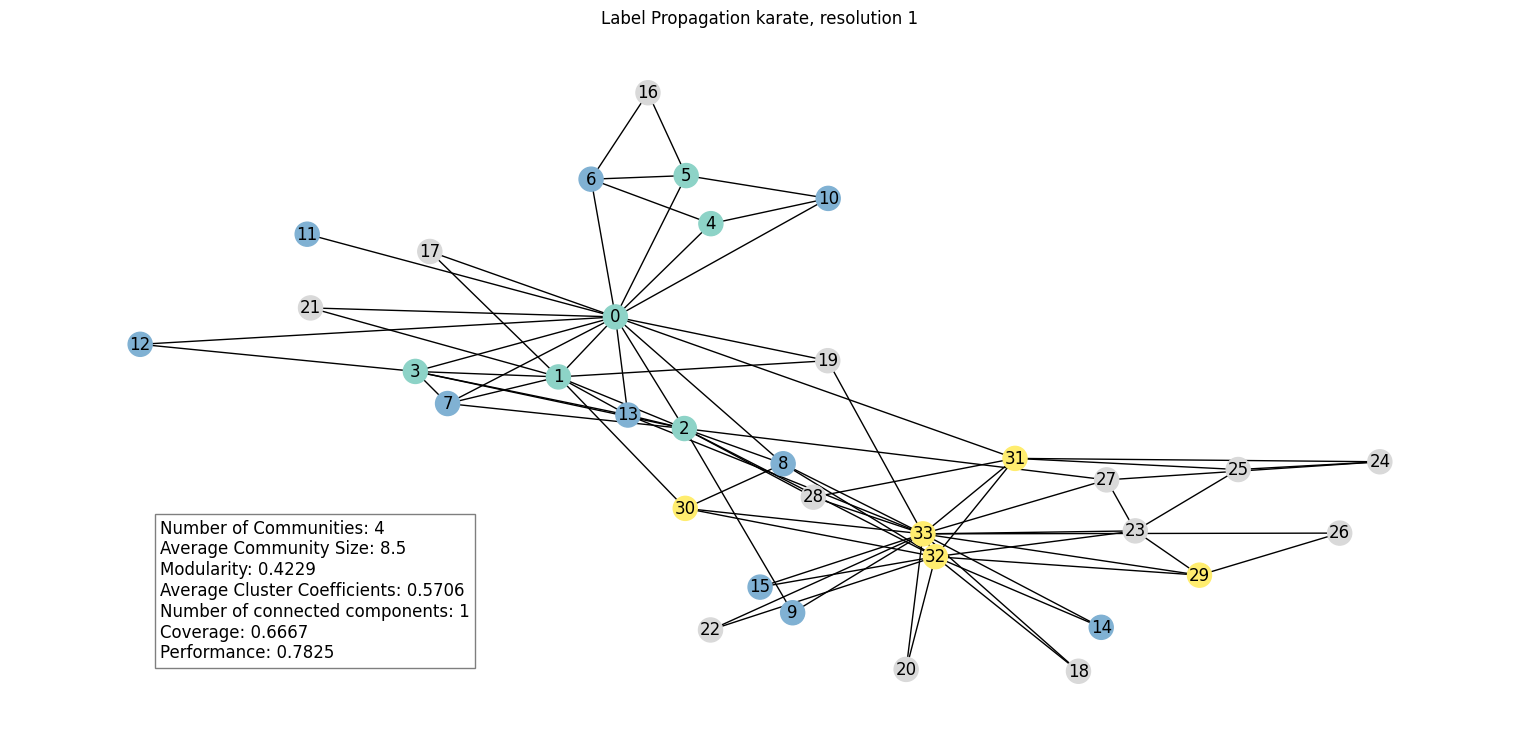

In [341]:
# default resolution
lv_labels = louvain(g, resolution=1)

# Calculate metrics for Louvain
lv_metrics = community_metrics(g, lv_labels)
lv_trials.append({**lv_metrics, 'Resolution': 1})
plot_communities(g, lv_labels, title=f"Label Propagation {sel_graph}, resolution 1", metrics=lv_metrics)

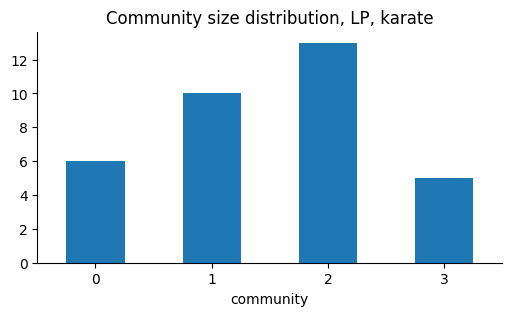

In [342]:
community_size_hist(lv_labels, title=f"Community size distribution, LP, {sel_graph}")

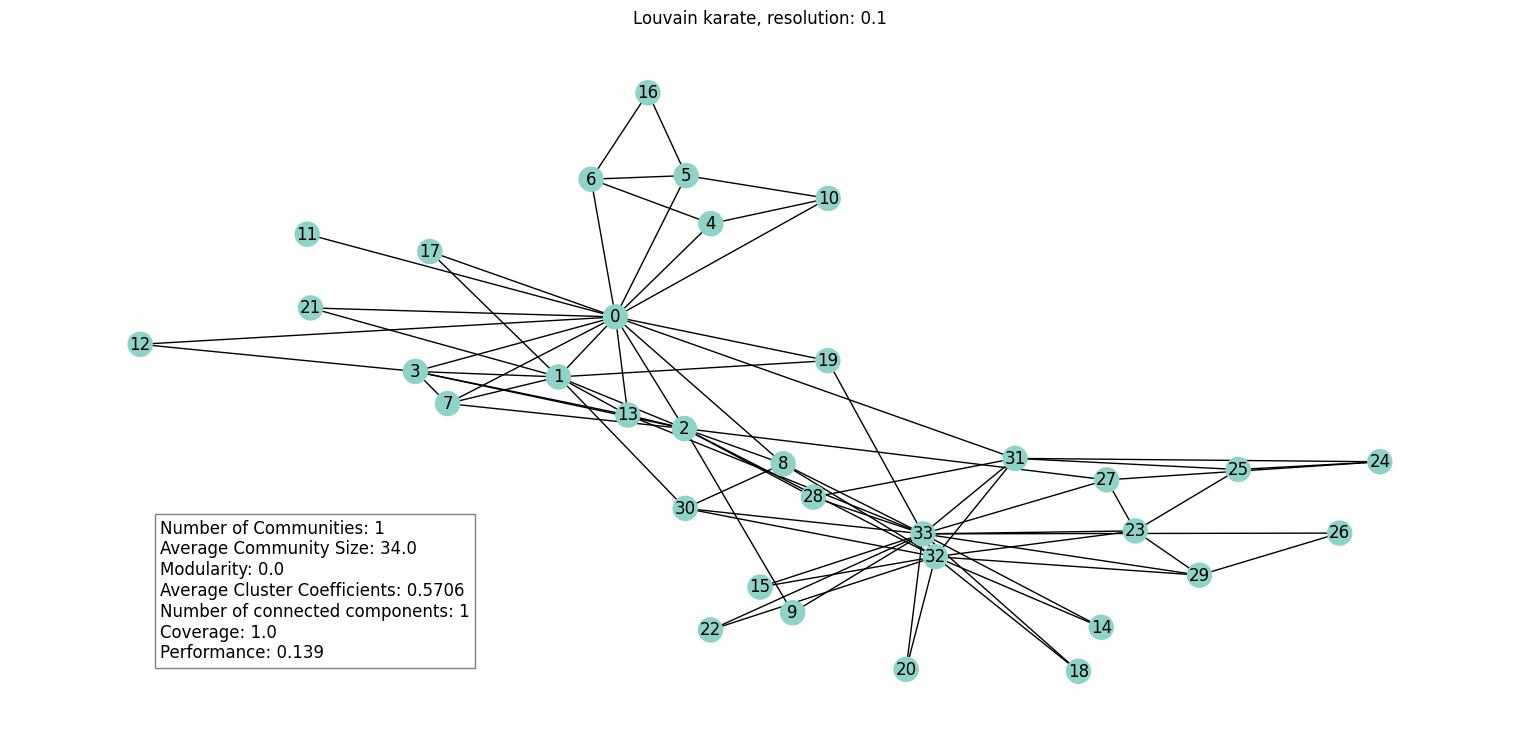

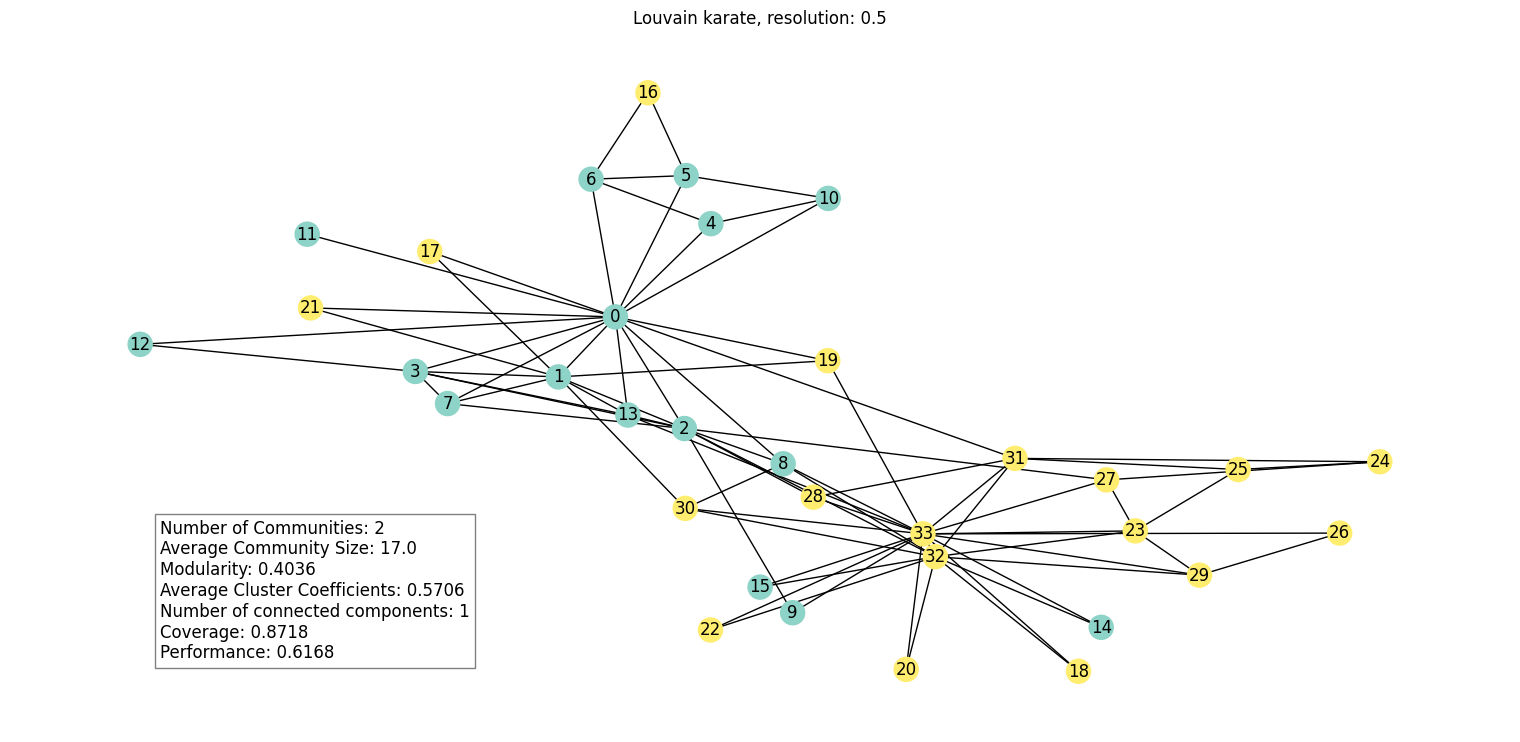

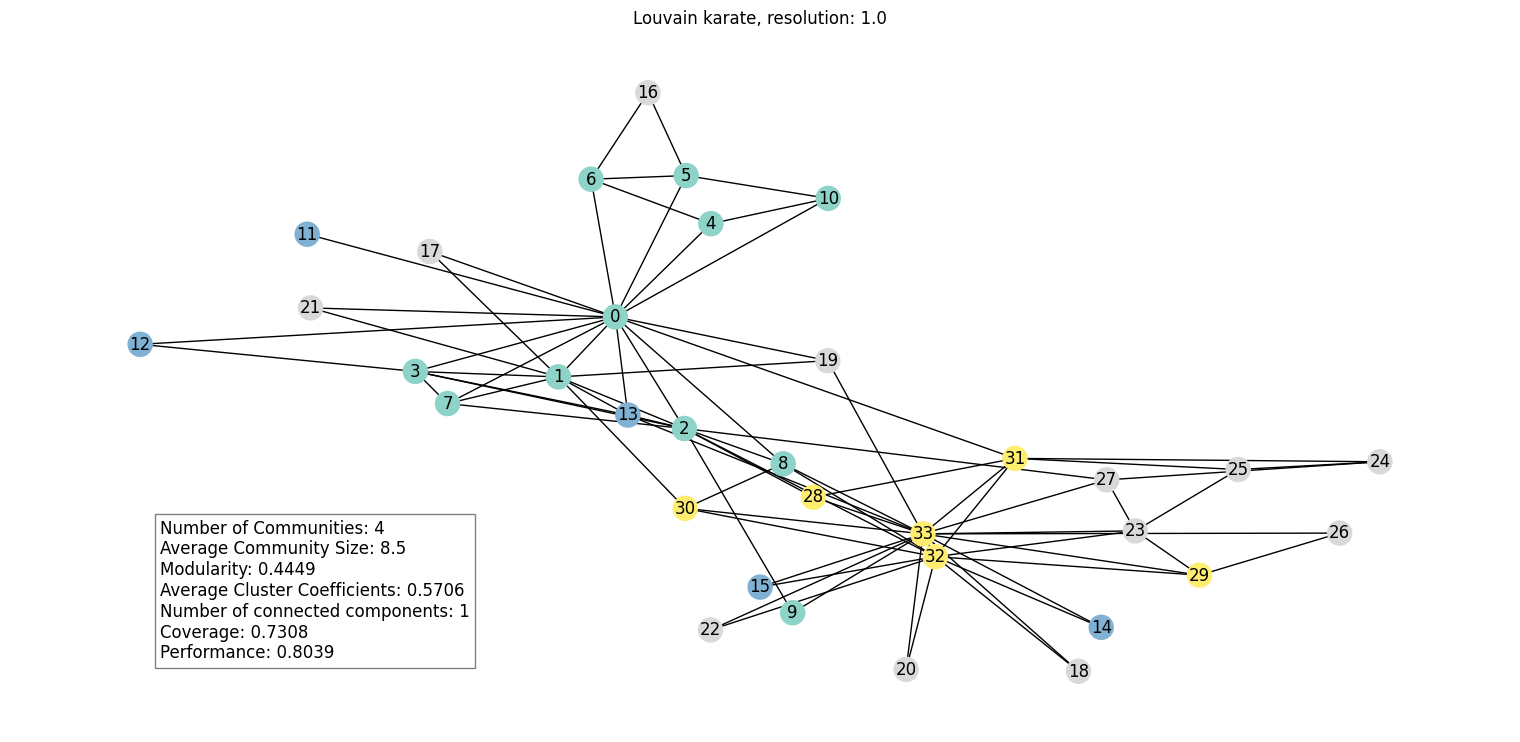

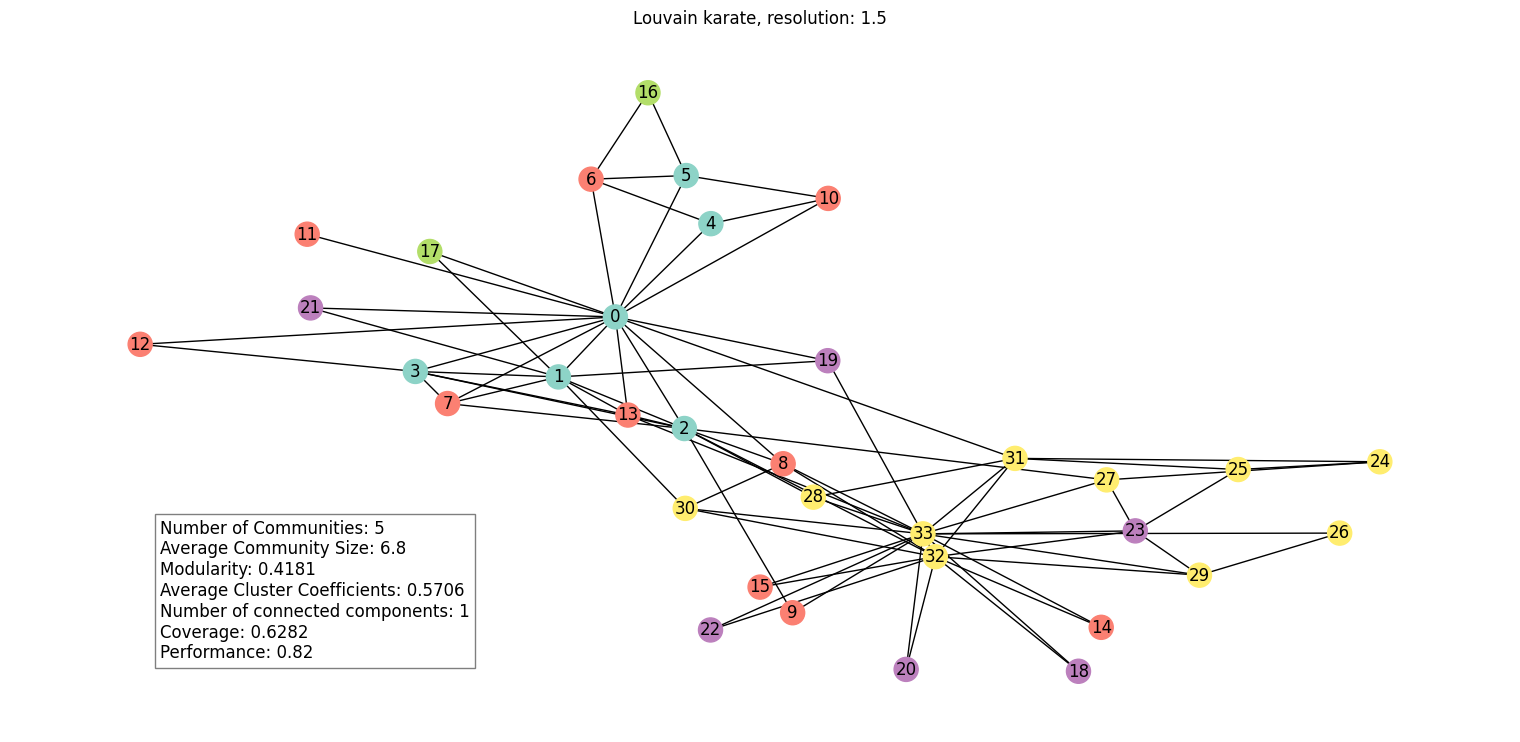

In [343]:
for i in (0.1, 0.5, 1.0, 1.5):
    lv_labels = louvain(g, resolution=i)

    # Calculate metrics for Louvain
    lv_metrics = community_metrics(g, lv_labels)
    lv_trials.append({**lv_metrics, 'Resolution': i})
    plot_communities(g, lv_labels, title=f"Louvain {sel_graph}, resolution: {i}", metrics=lv_metrics)

### Model evaluation

In [344]:
lv_df = pd.DataFrame(lv_trials)

# calculate execution time and metrics for best model
start_time = time.time()
lv_labels = louvain(g, resolution=lv_df.loc[lv_df['Modularity'].idxmax(), 'Resolution'])
end_time = time.time()
lv_time = end_time - start_time
lv_metrics = community_metrics(g, lv_labels)

## Leiden

### Hyperparameter selection

In [345]:
ld_trials = []

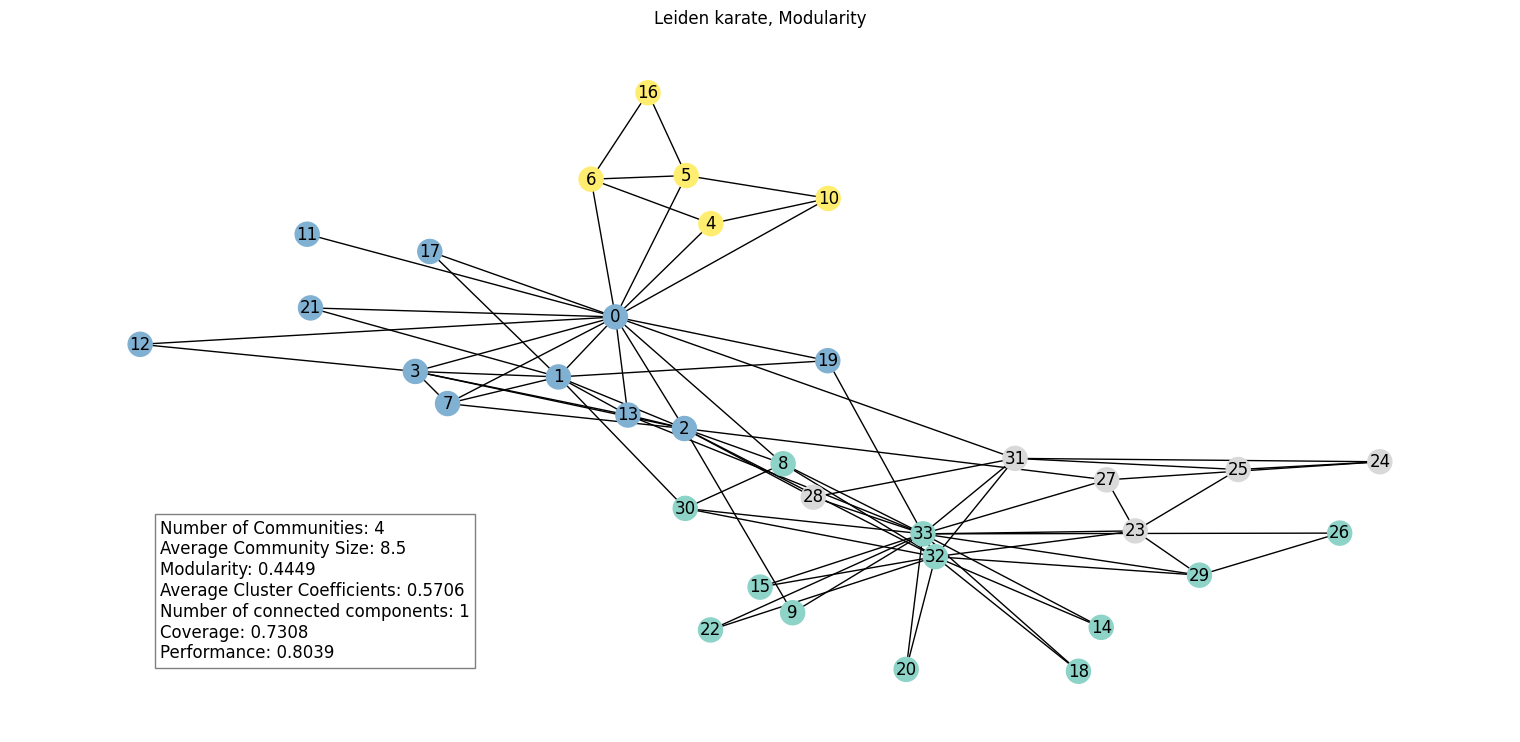

In [346]:
ld_labels = leiden(g)

# Calculate metrics for Leiden
ld_metrics = community_metrics(g, ld_labels)
ld_trials.append({**ld_metrics})
plot_communities(g, ld_labels, title=f"Leiden {sel_graph}, Modularity", metrics=ld_metrics)

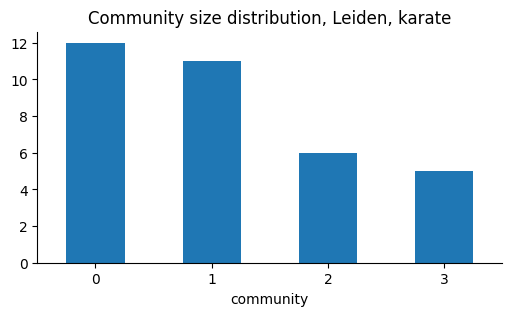

In [347]:
community_size_hist(ld_labels, title=f"Community size distribution, Leiden, {sel_graph}")

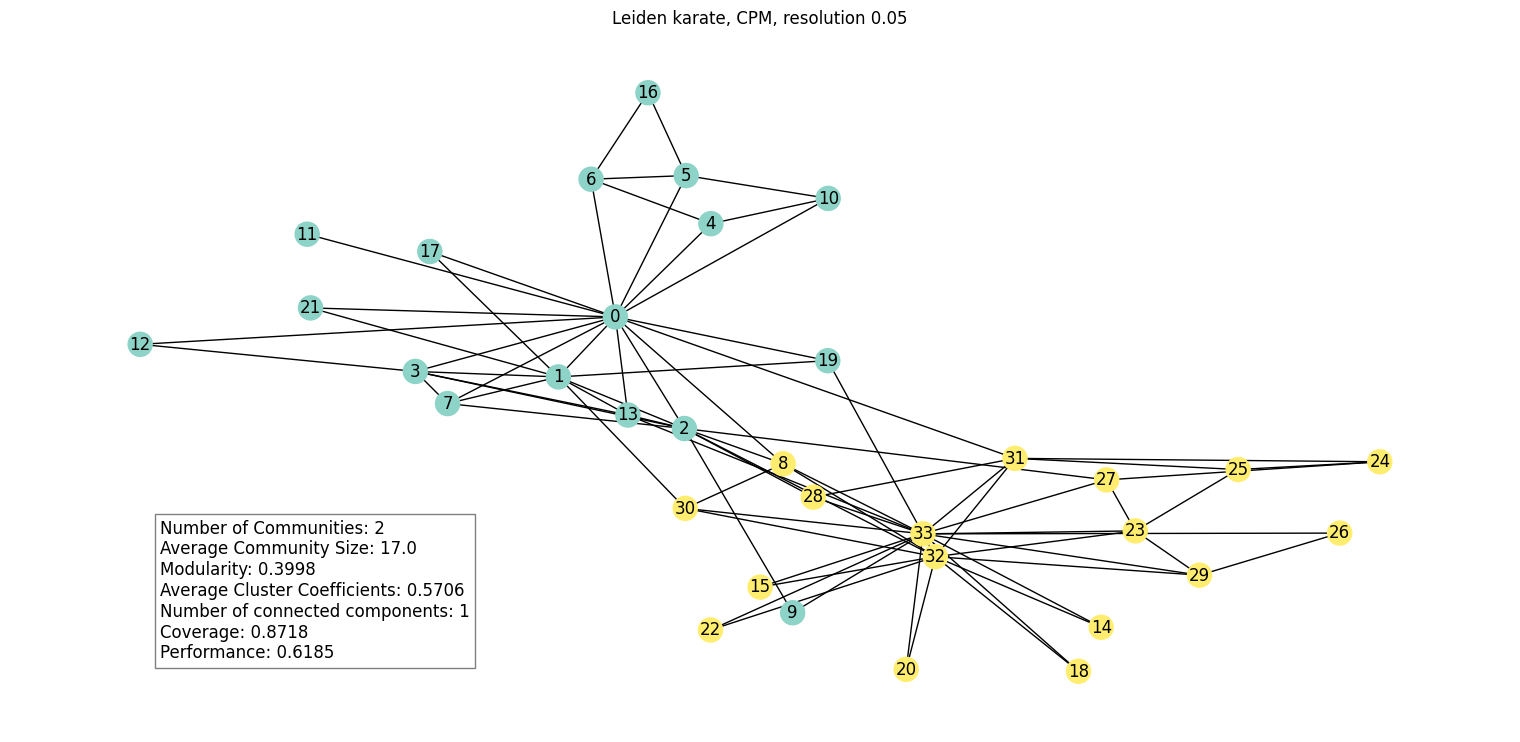

In [348]:
ld_labels = leiden(g, resolution=0.05)

# Calculate metrics for Leiden
ld_metrics = community_metrics(g, ld_labels)
ld_trials.append({**ld_metrics, 'Resolution': 0.05})
plot_communities(g, ld_labels, title=f"Leiden {sel_graph}, CPM, resolution 0.05", metrics=ld_metrics)

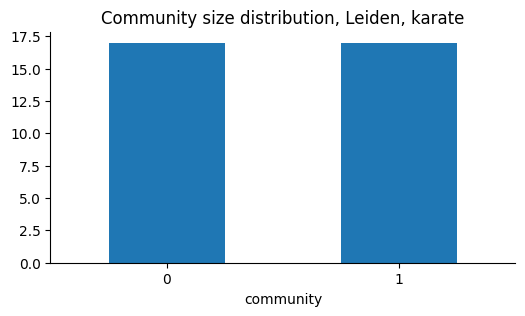

In [349]:
community_size_hist(ld_labels, title=f"Community size distribution, Leiden, {sel_graph}")

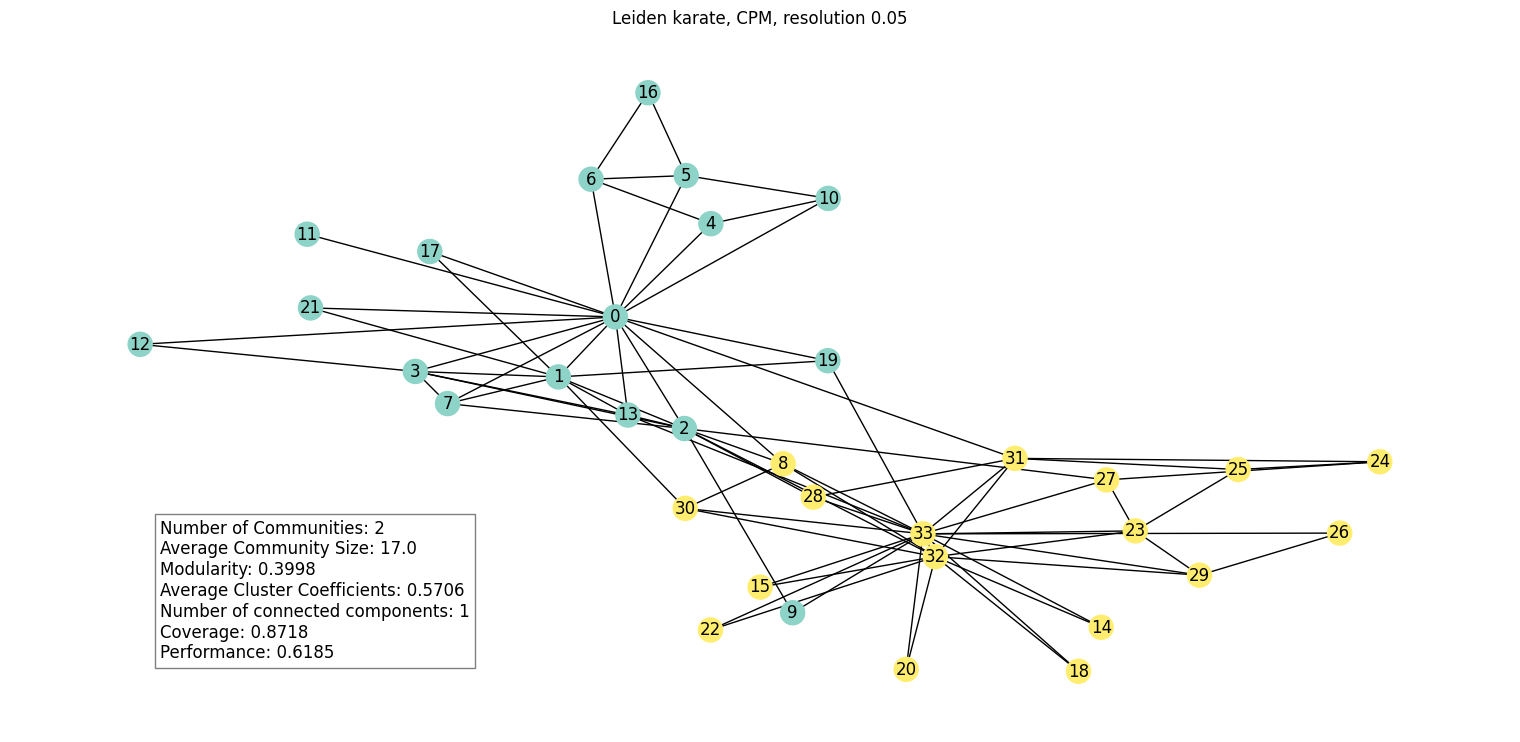

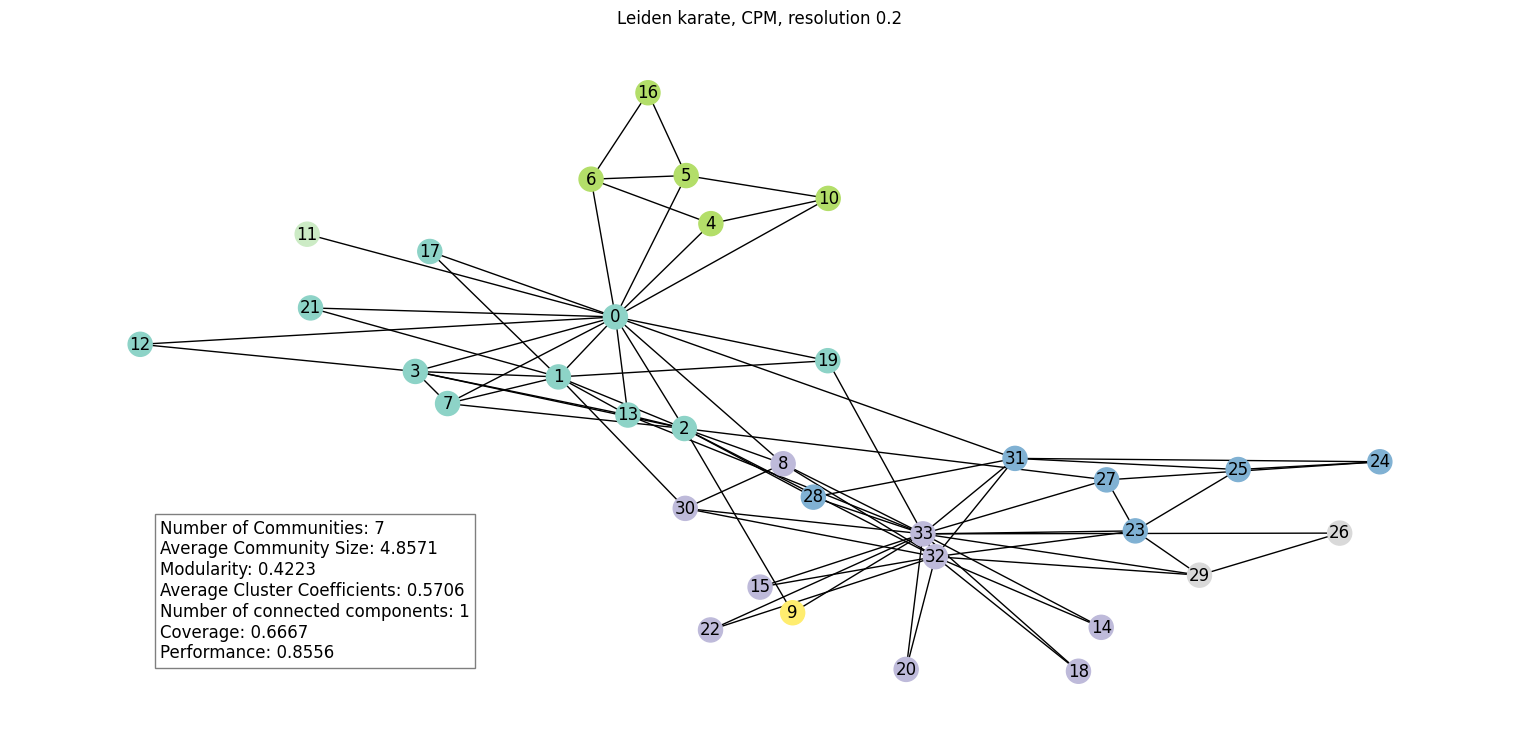

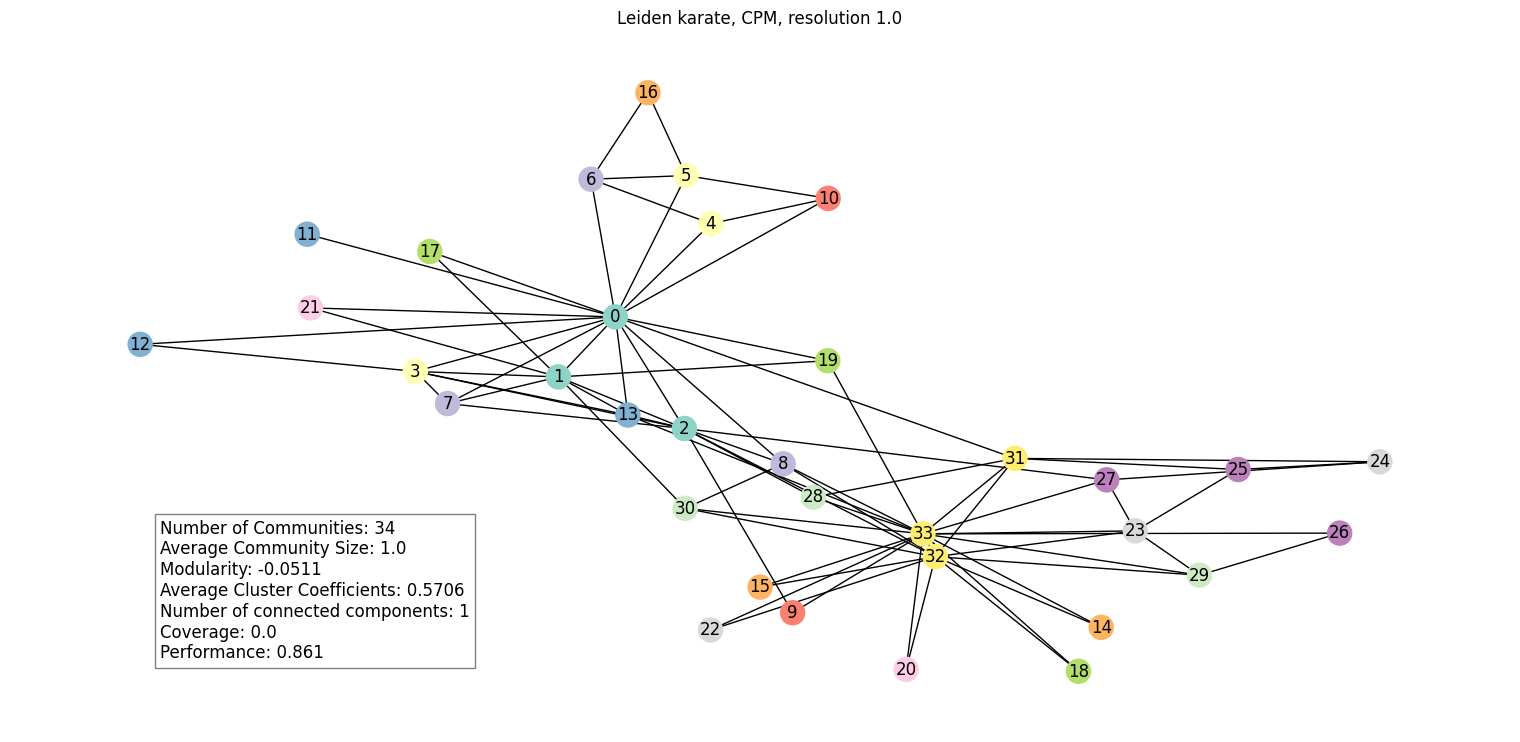

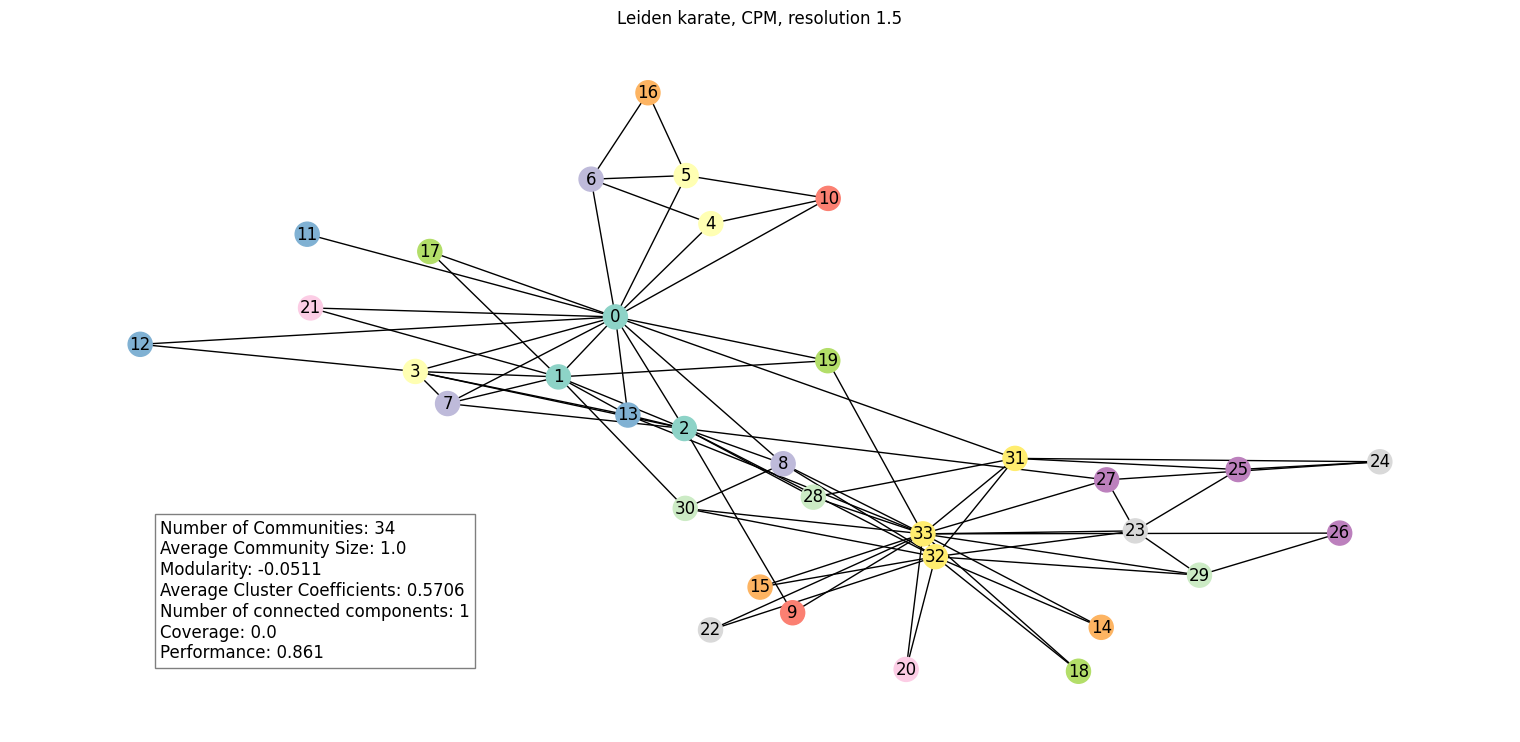

In [350]:
for i in (0.05, 0.2, 1.0, 1.5):
    ld_labels = leiden(g, resolution=i)

    # Calculate metrics for Leiden
    ld_metrics = community_metrics(g, ld_labels)
    ld_trials.append({**ld_metrics, 'Resolution': i})
    plot_communities(g, ld_labels, title=f"Leiden {sel_graph}, CPM, resolution {i}", metrics=ld_metrics)

### Model evaluation

In [351]:
ld_df = pd.DataFrame(ld_trials)

# calculate execution time and metrics for best model
start_time = time.time()
ld_labels = leiden(g, resolution=ld_df.loc[ld_df['Modularity'].idxmax(), 'Resolution'])
end_time = time.time()
ld_time = end_time - start_time
ld_metrics = community_metrics(g, ld_labels)

# Apply GAT Embedding

We will try to train GAT using 3 different loss function and compare the obtained results. The loss functions are:
1. DGI (Deep Graph Infomax)
2. Embedding variance
3. Contrastive loss between connected and unconnected nodes


In [73]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [74]:
# Convert networkx graph to PyTorch Geometric data object
data = from_networkx(g)

# Since the graph doesn't have node features, we use an identity matrix
data.x = torch.eye(g.number_of_nodes(), dtype=torch.float)

In [75]:
def predict_with_time(data, model, train_function, epochs, best_clustering_method):
    """
    Helper function to train a model on a provided data with a given train function.
    Returns a tuple (obtained community predictions, time for prediction).
    """
    
    # Start timing
    start_time = time.time()
    
    # Training the model
    for epoch in range(epochs):
        loss = train_function()
        if epoch % 10 == 0:
            print(f'Epoch {epoch}, Loss: {loss}')
    
    # Extract node embeddings
    model.eval()
    with torch.no_grad():
        try:
            node_embeddings = model(data).detach().cpu().numpy()
        except AttributeError:  # case DGI
            node_embeddings = model.encoder(data.x, data.edge_index).cpu().numpy()
    
    if best_clustering_method == "optics":
        # optics clustering
        _, _, gat_communities = optics(g, node_embeddings)
    else:
        # kmeans clustering
        _, _, gat_communities = kmeans(g, node_embeddings)
    
    # End timing
    end_time = time.time()
    # Calculate the elapsed time
    elapsed_time = end_time - start_time

    return gat_communities, elapsed_time

## DGI loss

### Hyperparameter selection

In [76]:
# Select best hyperparameters
best_parameters_optuna_dgi = tune(data)

[I 2024-08-13 01:27:54,956] A new study created in memory with name: no-name-3feb6c98-7c23-41fa-9c8e-34964a2b9e5e
[I 2024-08-13 01:27:56,236] Trial 0 finished with value: 0.41190006574621957 and parameters: {'hidden_channels': 24, 'out_channels': 32, 'heads': 11, 'learning_rate': 0.00012788154302704612, 'dropout': 0.26086108141605185, 'weight_decay': 1.0162124141900027e-05}. Best is trial 0 with value: 0.41190006574621957.
[I 2024-08-13 01:27:56,885] Trial 1 finished with value: 0.40203813280736356 and parameters: {'hidden_channels': 12, 'out_channels': 19, 'heads': 5, 'learning_rate': 0.0016551661844556224, 'dropout': 0.6455137817995925, 'weight_decay': 0.00040836620742954686}. Best is trial 0 with value: 0.41190006574621957.
[I 2024-08-13 01:27:57,553] Trial 2 finished with value: 0.16165351742274814 and parameters: {'hidden_channels': 47, 'out_channels': 29, 'heads': 2, 'learning_rate': 0.003205538980172368, 'dropout': 0.7001071733970342, 'weight_decay': 6.733556377182526e-05}. Best

In [77]:
# Best observed modularity
best_parameters_optuna_dgi.best_value

0.41978961209730437

In [78]:
# Save best params
best_parameters = best_parameters_optuna_dgi.best_params

hidden_channels = best_parameters['hidden_channels']
out_channels = best_parameters['out_channels']
heads = best_parameters['heads']
dropout = best_parameters['dropout']
lr = best_parameters['learning_rate']
l2_reg = best_parameters['weight_decay']
epochs = 100
num_layers = 2

best_method = best_parameters_optuna_dgi.best_trial.user_attrs['best_method']

### Model evaluation

In [79]:
# Define DGI model, optimizer, train function for DGI with optimal params
model = DGIModel(in_channels=data.num_features, hidden_channels=hidden_channels, out_channels=out_channels, num_layers=num_layers, heads=heads, dropout=dropout)
model = model.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=l2_reg)


def train():
    model.train()
    optimizer.zero_grad()
    pos_z, neg_z, summary = model(data)
    loss = model.dgi.loss(pos_z, neg_z, summary)
    loss.backward()
    optimizer.step()
    return loss.item()

In [80]:
# get predictions with best model and record time spent on that
gat_dgi_communities, time_dgi = predict_with_time(data, model, train, epochs, best_method)

Epoch 0, Loss: 1.4096901416778564
Epoch 10, Loss: 1.4012316465377808
Epoch 20, Loss: 1.3525004386901855
Epoch 30, Loss: 1.3817754983901978
Epoch 40, Loss: 1.3515337705612183
Epoch 50, Loss: 1.3482654094696045
Epoch 60, Loss: 1.365278720855713
Epoch 70, Loss: 1.3531837463378906
Epoch 80, Loss: 1.3396010398864746
Epoch 90, Loss: 1.2696441411972046


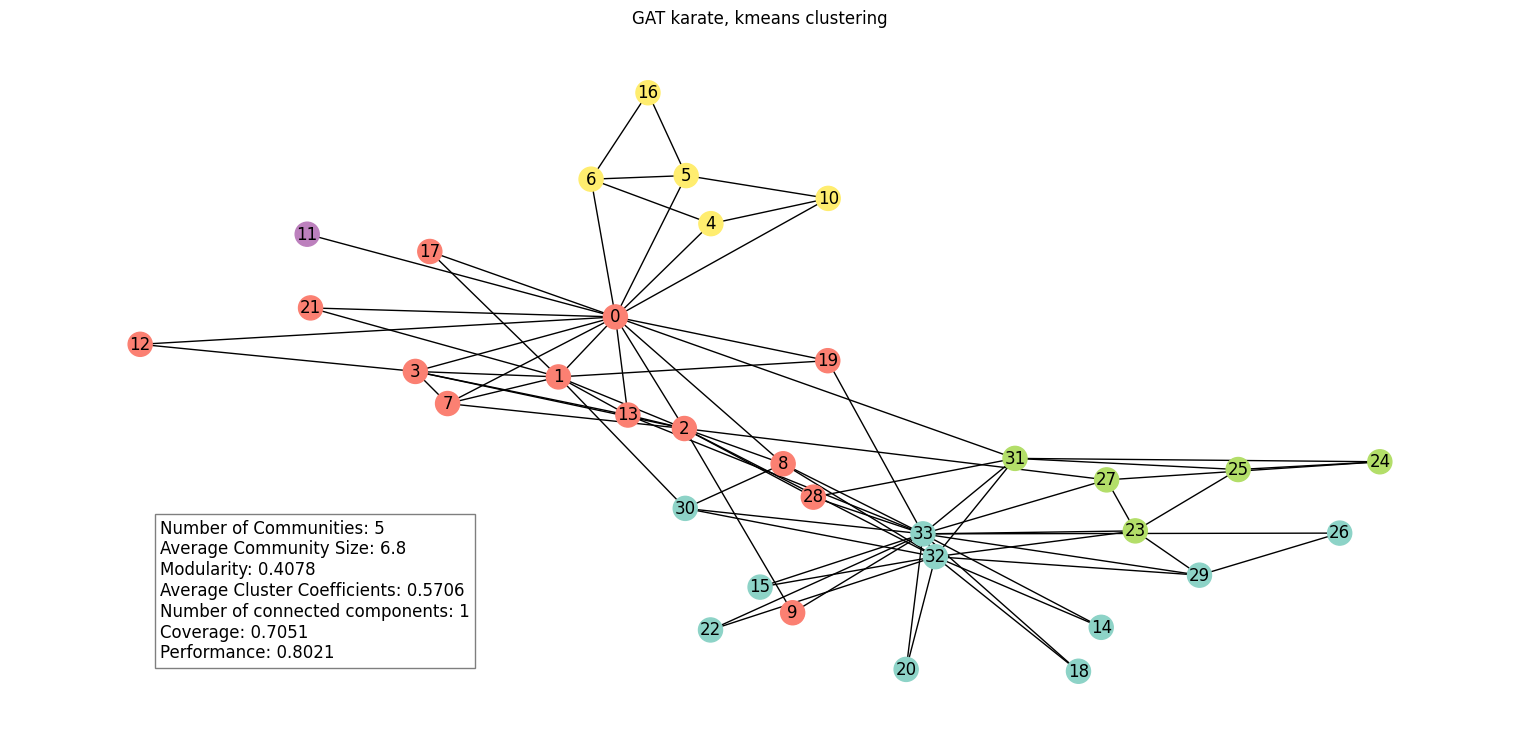

In [81]:
# Print results for the best parameters and best clustering method
gat_dgi_metrics = community_metrics(g, gat_dgi_communities)
plot_communities(g, gat_dgi_communities, title=f"GAT {sel_graph}, {best_method} clustering", metrics=gat_dgi_metrics)

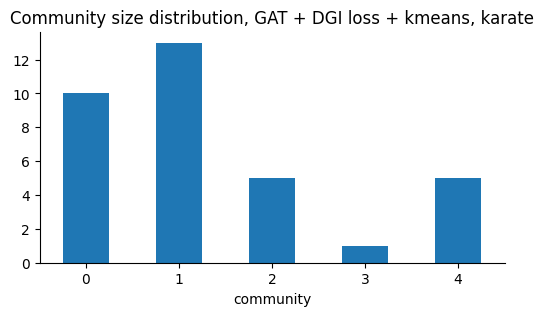

In [82]:
community_size_hist(gat_dgi_communities, title=f"Community size distribution, GAT + DGI loss + {best_method}, {sel_graph}")

## Embedding variance loss

### Hyperparameter selection

In [86]:
best_parameters_optuna_var = tune_variance_contrastive(data, g, loss_function="variance")

[I 2024-08-13 01:31:25,954] A new study created in memory with name: no-name-b5649a1a-35d8-4947-8b3a-74c97d8bc62d


[I 2024-08-13 01:31:26,365] Trial 0 finished with value: 0.4345214669889994 and parameters: {'hidden_channels': 14, 'out_channels': 30, 'heads': 4, 'learning_rate': 0.0008351058920557128, 'dropout': 0.22532573198237654, 'weight_decay': 0.0004973730404620761}. Best is trial 0 with value: 0.4345214669889994.
[I 2024-08-13 01:31:26,668] Trial 1 finished with value: 0.2440546466520493 and parameters: {'hidden_channels': 17, 'out_channels': 6, 'heads': 14, 'learning_rate': 0.0009060203424725354, 'dropout': 0.42056578220929697, 'weight_decay': 5.2818116438057094e-05}. Best is trial 0 with value: 0.4345214669889994.
[I 2024-08-13 01:31:26,992] Trial 2 finished with value: 0.4248795937107625 and parameters: {'hidden_channels': 41, 'out_channels': 23, 'heads': 4, 'learning_rate': 0.0001853052776881881, 'dropout': 0.6473048446659148, 'weight_decay': 9.825142494925007e-05}. Best is trial 0 with value: 0.4345214669889994.
/home/jann/GAT/venv/lib/python3.10/site-packages/sklearn/cluster/_optics.py:

In [87]:
# Best observed modularity
best_parameters_optuna_var.best_value

0.44018103109012197

In [88]:
best_parameters = best_parameters_optuna_var.best_params

hidden_channels = best_parameters['hidden_channels']
out_channels = best_parameters['out_channels']
heads = best_parameters['heads']
dropout = best_parameters['dropout']
lr = best_parameters['learning_rate']
l2_reg = best_parameters['weight_decay']
epochs = 100
num_layers = 2

best_method = best_parameters_optuna_var.best_trial.user_attrs['best_method']

### Model evaluation

In [89]:
# Define GAT model with embedding variance loss functions
# Define optimizer, train function for GAT with optimal params
model = GAT(num_features=data.num_features, hidden_channels=hidden_channels, out_channels=out_channels, num_heads=heads, dropout=dropout)
model = model.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=l2_reg)

def train():
    model.train()
    optimizer.zero_grad()
    out = model(data)
    loss = -torch.var(out)
    loss.backward()
    optimizer.step()
    return loss.item()

In [90]:
# get predictions with best model and record time spent on that
gat_var_communities, time_var = predict_with_time(data, model, train, epochs, best_method)

Epoch 0, Loss: -0.0009511744137853384
Epoch 10, Loss: -0.0014399508945643902
Epoch 20, Loss: -0.002586142625659704
Epoch 30, Loss: -0.0034341304562985897
Epoch 40, Loss: -0.005677974317222834
Epoch 50, Loss: -0.009646263904869556
Epoch 60, Loss: -0.01839124783873558
Epoch 70, Loss: -0.025352351367473602
Epoch 80, Loss: -0.04880258068442345
Epoch 90, Loss: -0.08383527398109436


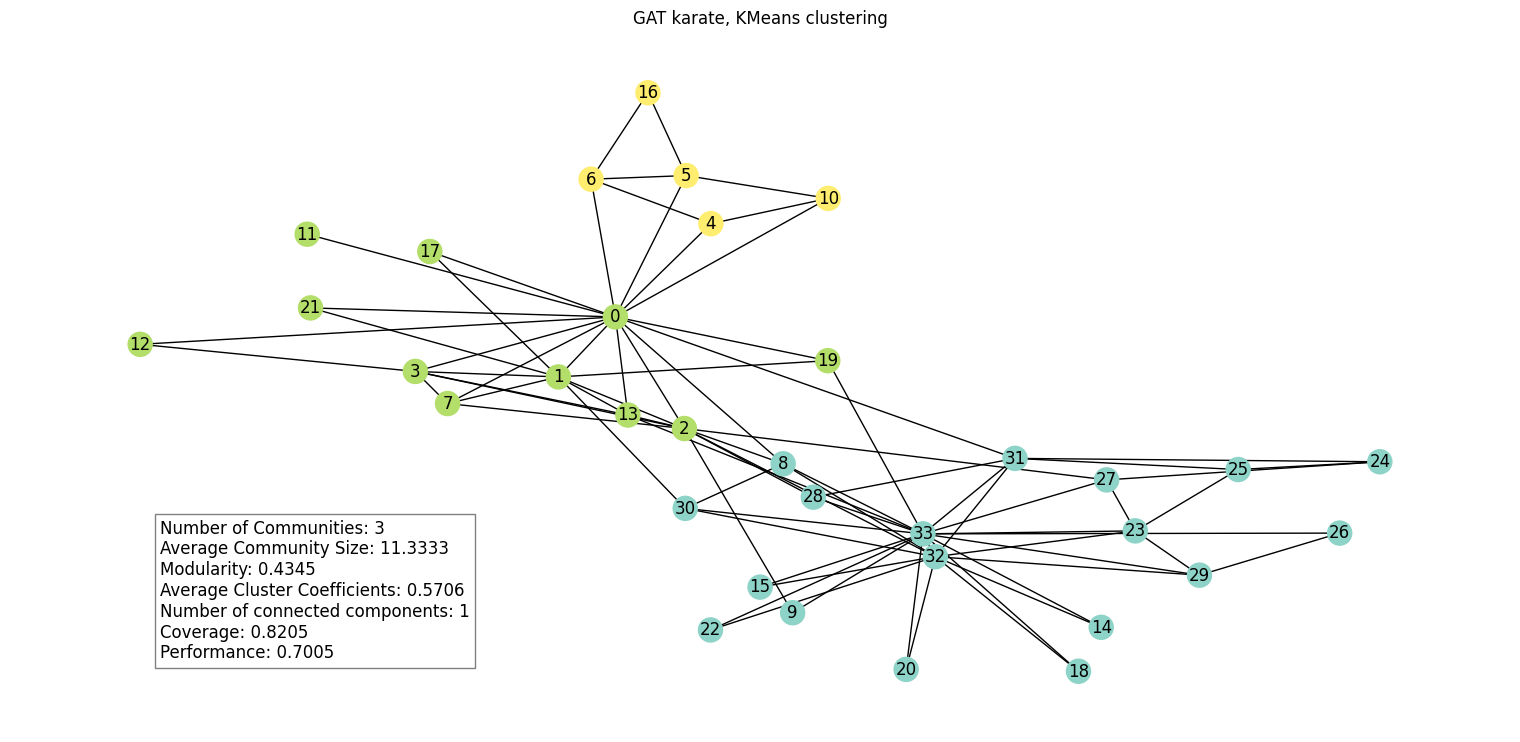

In [91]:
# get visualizations and metrics
gat_var_metrics = community_metrics(g, gat_var_communities)
plot_communities(g, gat_var_communities, title=f"GAT {sel_graph}, {best_method} clustering", metrics=gat_var_metrics)

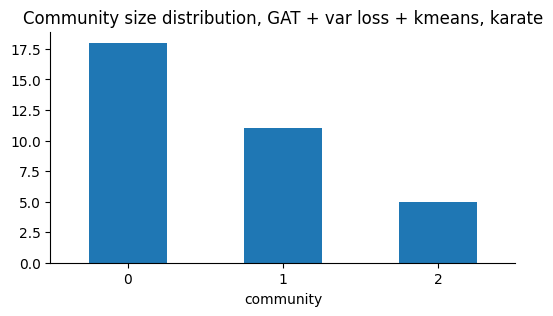

In [92]:
community_size_hist(gat_var_communities, title=f"Community size distribution, GAT + var loss + {best_method}, {sel_graph}")

## Contrastive loss

### Hyperparameter selection

In [93]:
best_parameters_optuna_con = tune_variance_contrastive(data, g, loss_function="contrastive")

[I 2024-08-13 01:31:43,439] A new study created in memory with name: no-name-ac65e5ca-e5d4-46e5-bdeb-f482e993119d


[I 2024-08-13 01:31:45,173] Trial 0 finished with value: 0.424720301343678 and parameters: {'hidden_channels': 38, 'out_channels': 29, 'heads': 2, 'learning_rate': 0.0012947275411794633, 'dropout': 0.1187020316855541, 'weight_decay': 1.169674763835535e-05}. Best is trial 0 with value: 0.424720301343678.
[I 2024-08-13 01:31:46,904] Trial 1 finished with value: 0.4075167256985438 and parameters: {'hidden_channels': 14, 'out_channels': 11, 'heads': 16, 'learning_rate': 0.00045070409727928534, 'dropout': 0.3139317980463216, 'weight_decay': 0.00032448751947497913}. Best is trial 0 with value: 0.424720301343678.
[I 2024-08-13 01:31:48,672] Trial 2 finished with value: 0.3955042071925189 and parameters: {'hidden_channels': 36, 'out_channels': 17, 'heads': 11, 'learning_rate': 0.002115638476534376, 'dropout': 0.2354625421667306, 'weight_decay': 0.0001920952742467998}. Best is trial 0 with value: 0.424720301343678.
[I 2024-08-13 01:31:50,406] Trial 3 finished with value: 0.40362811791383213 and

In [94]:
# Best observed modularity
best_parameters_optuna_con.best_value

0.44490358126721763

In [95]:
best_parameters = best_parameters_optuna_con.best_params

hidden_channels = best_parameters['hidden_channels']
out_channels = best_parameters['out_channels']
heads = best_parameters['heads']
dropout = best_parameters['dropout']
lr = best_parameters['learning_rate']
l2_reg = best_parameters['weight_decay']
epochs = 100

best_clustering_method = best_parameters_optuna_con.best_trial.user_attrs['best_method']

### Model evaluation

In [96]:
# Define GAT model with contrastive loss functions
# Define optimizer, train function for GAT with optimal params

model = GAT(num_features=data.num_features, hidden_channels=hidden_channels, out_channels=out_channels, num_heads=heads, dropout=dropout)
model = model.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=l2_reg)

def train():
    model.train()
    optimizer.zero_grad()
    out = model(data)
    loss = contrastive_loss(out, g)
    loss.backward()
    optimizer.step()
    return loss.item()

In [97]:
gat_con_communities, time_con = predict_with_time(data, model, train, epochs, best_method)

Epoch 0, Loss: 0.43038251996040344
Epoch 10, Loss: 0.16145727038383484
Epoch 20, Loss: 0.06088276579976082
Epoch 30, Loss: 0.05532306805253029
Epoch 40, Loss: 0.05666565150022507
Epoch 50, Loss: 0.05689578875899315
Epoch 60, Loss: 0.058877114206552505
Epoch 70, Loss: 0.05225461721420288
Epoch 80, Loss: 0.04955968260765076
Epoch 90, Loss: 0.05003662034869194


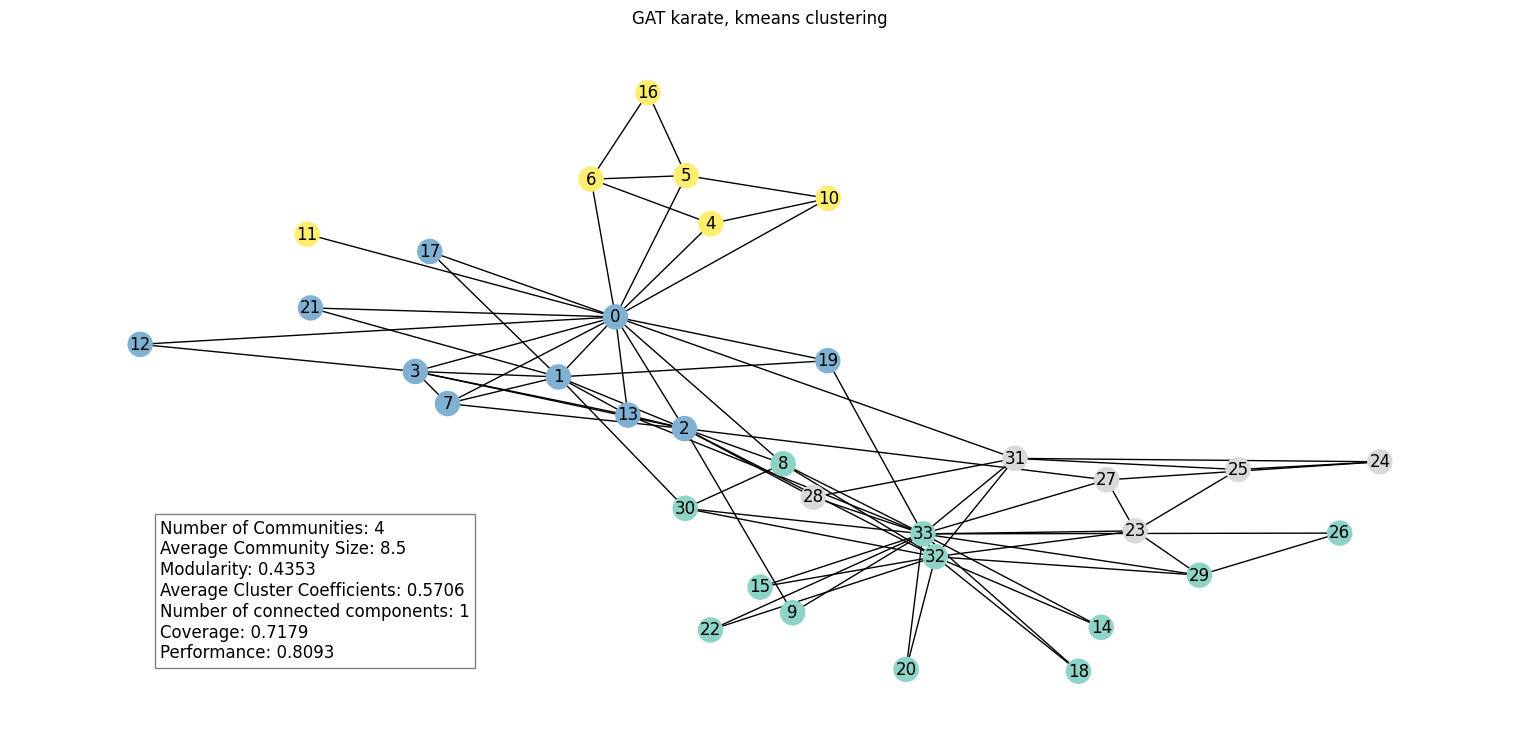

In [98]:
gat_con_metrics = community_metrics(g, gat_con_communities)
plot_communities(g, gat_con_communities, title=f"GAT {sel_graph}, {best_method} clustering", metrics=gat_con_metrics)

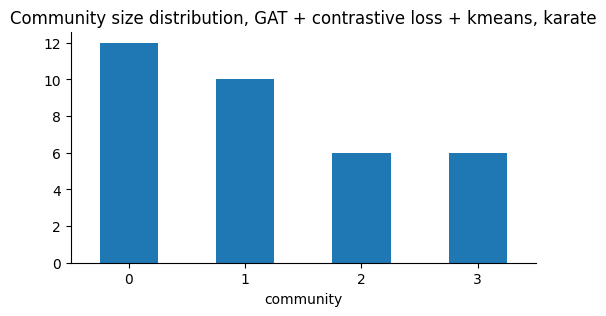

In [99]:
community_size_hist(gat_con_communities, title=f"Community size distribution, GAT + contrastive loss + {best_method}, {sel_graph}")

# Final result

## Modularities

In [100]:
lp_metrics["Modularity"]

0.30948632896684847

In [101]:
lv_metrics["Modularity"]

0.42662243960945256

In [102]:
ld_metrics["Modularity"]

0.44490358126721763

In [103]:
gat_dgi_metrics["Modularity"]

0.40777908959727144

In [104]:
gat_var_metrics["Modularity"]

0.4345214669889994

In [105]:
gat_con_metrics["Modularity"]

0.43526170798898073

## Execution times (CPU)

In [106]:
lp_time

0.00027298927307128906

In [107]:
lv_time

0.0007596015930175781

In [108]:
ld_time

0.0011332035064697266

In [109]:
time_dgi

0.6204338073730469

In [110]:
time_var

0.3137335777282715

In [111]:
time_con

1.7177903652191162